<a href="https://colab.research.google.com/github/abrilestrada/Abs/blob/master/02_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks for Biomedical Image Analysis
### A 1‑Hour Hands‑On Course

Welcome! In this short course, you will learn how to use **Convolutional Neural Networks (CNNs)** to classify medical images – specifically, chest X‑rays to detect pneumonia.

**What you will learn:**
- What CNNs are and why they excel at image tasks
- How to load and prepare a biomedical image dataset
- How to build a CNN using `Conv2D`, `MaxPooling2D`, and `Dense` layers
- How to train, evaluate, and improve the model with data augmentation

**Dataset:** PneumoniaMNIST (from MedMNIST) – 28×28 grayscale chest X‑rays, labelled `0` (normal) or `1` (pneumonia).

Let’s begin!

## Step 1: Setup and Data Loading (10 minutes)

We will install the `medmnist` package, load the PneumoniaMNIST dataset, and explore a few images.

In [ ]:
# Install required packages (run once)
!pip install -q medmnist tensorflow matplotlib seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import medmnist
from medmnist import PneumoniaMNIST

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Download and load the dataset
data_train = PneumoniaMNIST(split='train', download=True)
data_val = PneumoniaMNIST(split='val', download=True)
data_test = PneumoniaMNIST(split='test', download=True)

# Extract images and labels
X_train, y_train = data_train.imgs, data_train.labels
X_val, y_val = data_val.imgs, data_val.labels
X_test, y_test = data_test.imgs, data_test.labels

# Normalize pixel values to [0,1]
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# Flatten the labels (from one column to 1D array)
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

print(f"Training set: {X_train.shape} images, labels shape {y_train.shape}")
print(f"Validation set: {X_val.shape} images")
print(f"Test set: {X_test.shape} images")
print(f"Classes: 0=Normal, 1=Pneumonia")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.4 MB/s eta 0:00:00


100%|██████████| 4.17M/4.17M [00:00<00:00, 6.30MB/s]


Training set: (4708, 28, 28) images, labels shape (4708,)
Validation set: (524, 28, 28) images
Test set: (624, 28, 28) images
Classes: 0=Normal, 1=Pneumonia


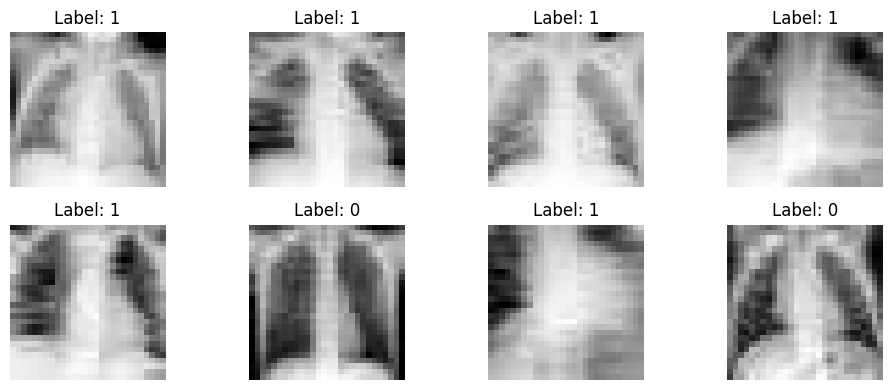

In [ ]:
# Visualize some sample images
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Build a Convolutional Neural Network (15 minutes)

A CNN consists of **convolutional layers** (which detect patterns like edges or textures), **pooling layers** (which downsample and reduce computation), and **dense layers** (which perform classification based on the extracted features).

We will build a simple CNN with:
- Two convolutional + pooling blocks
- A flatten layer to convert 2D features into a 1D vector
- Two dense layers (with dropout to reduce overfitting)
- A final output layer with sigmoid activation (binary classification)

In [ ]:
model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    # Second convolutional block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,345 (474.00 KB)

 Trainable params: 121,345 (474.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Compile and Train the CNN (20 minutes)

We will use the **Adam optimizer** and **binary crossentropy** loss, which is standard for binary classification. We also track **accuracy**.

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,          # Keep low for speed (10 epochs ~ 1-2 minutes)
                    batch_size=32,
                    verbose=1)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.8003 - loss: 0.4351 - val_accuracy: 0.9179 - val_loss: 0.2349
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9051 - loss: 0.2401 - val_accuracy: 0.9408 - val_loss: 0.1747
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9244 - loss: 0.1924 - val_accuracy: 0.9408 - val_loss: 0.1536
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9350 - loss: 0.1756 - val_accuracy: 0.9447 - val_loss: 0.1409
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9363 - loss: 0.1673 - val_accuracy: 0.9542 - val_loss: 0.1192
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9452 - loss: 0.1498 - val_accuracy: 0.9542 - val_loss: 0.1102
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9460 - loss: 0.1428 - val_accuracy: 0.9542 - val_loss: 0.0998
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9465 - loss: 0.1461 - val_a

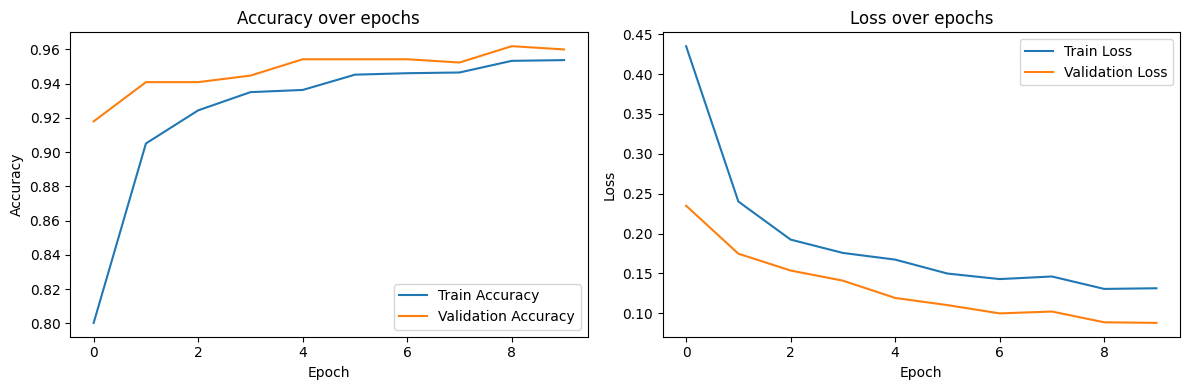

In [ ]:
# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')
plt.tight_layout()
plt.show()

## Step 4: Evaluate on the Test Set (10 minutes)

We now measure how well our CNN generalises to completely unseen X‑ray images.

Test Accuracy: 0.8365
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


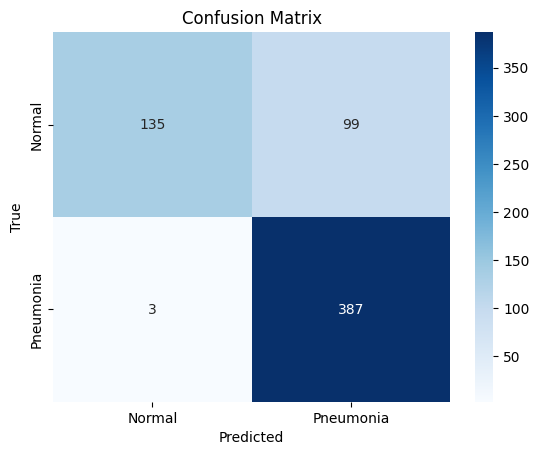


Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.58      0.73       234
   Pneumonia       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.86      0.84      0.82       624



In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Predict probabilities and convert to binary predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

## Step 5: (Optional) Improve Performance with Data Augmentation

Data augmentation artificially increases the variety of training images by applying random rotations, shifts, zooms, etc. This often improves generalization, especially for small medical datasets.

We will rebuild the same model and train it with augmented data. Because we only have 5 minutes left, we will use the same architecture but apply augmentation using `ImageDataGenerator`.

In [ ]:
tf.expand_dims(X_train, -1).shape

TensorShape([4708, 28, 28, 1])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an augmented data generator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Fit the generator on the training data
datagen.fit(tf.expand_dims(X_train, -1))

# Build the same model (reset weights)
aug_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

aug_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train using the augmented generator
history_aug = aug_model.fit(datagen.flow(tf.expand_dims(X_train, -1), y_train, batch_size=32),
                            validation_data=(X_val, y_val),
                            epochs=10,
                            verbose=1)

# Evaluate the augmented model
aug_test_acc = aug_model.evaluate(X_test, y_test, verbose=0)[1]
print(f"\nTest accuracy with data augmentation: {aug_test_acc:.4f}")
print(f"Improvement over baseline: {aug_test_acc - test_acc:.4f}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.7604 - loss: 0.5071 - val_accuracy: 0.8588 - val_loss: 0.3194
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8532 - loss: 0.3301 - val_accuracy: 0.8798 - val_loss: 0.2666
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8834 - loss: 0.2778 - val_accuracy: 0.9084 - val_loss: 0.2259
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.8995 - loss: 0.2525 - val_accuracy: 0.8912 - val_loss: 0.2402
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9055 - loss: 0.2371 - val_accuracy: 0.9332 - val_loss: 0.1668
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9061 - loss: 0.2325 - val_accuracy: 0.8931 - val_loss: 0.2295
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9125 - loss: 0.2133 - val_accuracy: 0.9275 - val_loss: 0.1686
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9199 - loss: 0.2026 - val_accuracy: 0.92

## Challenge (if time permits)

Try to improve the model even further by:
*   Adding more convolutional layers (e.g., 3 blocks).
*   Increasing the number of filters (e.g., 64 → 128).
*   Changing the dropout rate or adding batch normalisation.
*   Training for more epochs (but watch for overfitting).

**Write your improved model below and compare its test accuracy.**

In [ ]:
# Your improved CNN here
# improved_model = ...
# improved_model.compile(...)
# improved_model.fit(...)
# improved_test_acc = ...
# print(f"Improved Test Accuracy: {improved_test_acc:.4f}")

## Congratulations!

You have successfully:
- Loaded a real biomedical image dataset
- Built, trained, and evaluated a CNN for pneumonia detection
- Applied data augmentation to boost performance

**Next steps:**
- Try other MedMNIST datasets (e.g., PathMNIST for pathology, BreastMNIST for ultrasound)
- Explore transfer learning (using pre-trained models like ResNet) on medical images
- Deploy your model as a simple web app using TensorFlow.js or Flask

Keep learning and applying CNNs to solve real healthcare problems!